In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
dataset= pd.read_csv('D:/Github_project/Diabetes.csv')
dataset

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1
...,...,...,...
990,45,87,0
991,40,83,0
992,40,83,0
993,40,60,1


In [13]:
X=dataset.drop('diabetes', axis=1)
y=dataset['diabetes']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=70)

In [17]:
def gaussian_pdf(x, mu, sigma):
    return (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-((x-mu)**2)/(2*sigma**2))


Glucose0 mean: 44.094567404426556
Glucose0 sigma: 3.6969059149575654


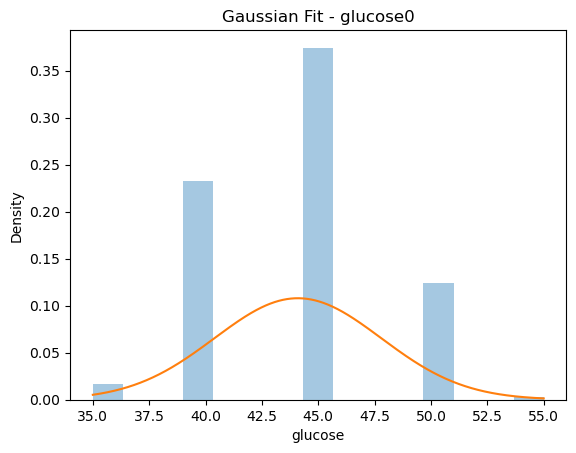

Bloodpressure0 mean: 86.738430583501
Bloodpressure0 sigma: 4.590047959869423


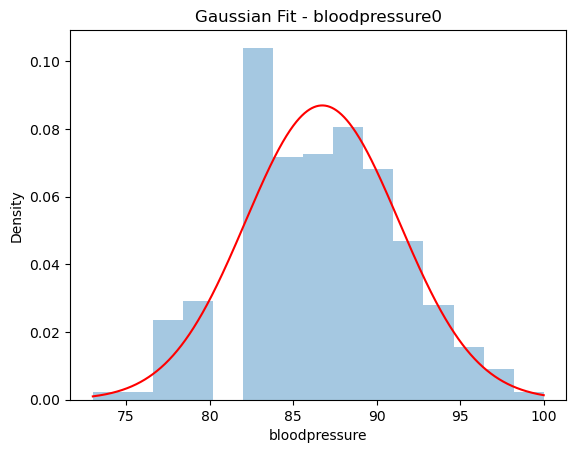

Glucose1 mean: 44.51807228915663
Glucose1 sigma: 8.721981802609738


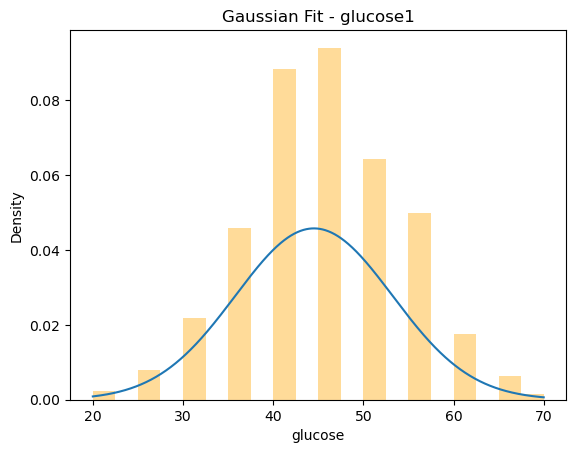

Bloodpressure1 mean: 71.64658634538152
Bloodpressure1 sigma: 6.281427895952204


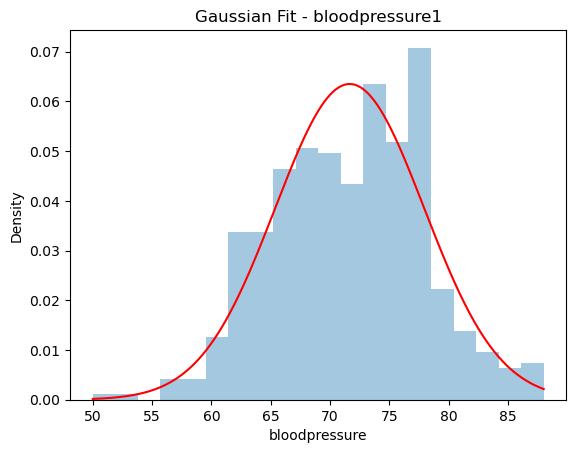

In [53]:
x0= dataset[dataset['diabetes']==0]
x1=dataset[dataset['diabetes']==1]

#class 0

glucose0 =x0['glucose']
bloodpressure0=x0['bloodpressure']

glucose0_mu= np.mean(glucose0)
glucose0_sigma= np.std(glucose0)
print(f'Glucose0 mean: {glucose0_mu}')
print(f'Glucose0 sigma: {glucose0_sigma}')

x_glucose0= np.linspace(min(glucose0), max(glucose0), 1000)
pdf_glucose0=gaussian_pdf(x_glucose0, glucose0_mu, glucose0_sigma)

plt.figure()
plt.hist(glucose0, bins=15, density=True, alpha=0.4)
plt.plot(x_glucose0, pdf_glucose0)
plt.title("Gaussian Fit - glucose0")
plt.xlabel("glucose")
plt.ylabel("Density")
plt.show()


bloodpressure0_mu=x0['bloodpressure'].mean()
bloodpressure0_sigma=x0['bloodpressure'].std()
print(f'Bloodpressure0 mean: {bloodpressure0_mu}')
print(f'Bloodpressure0 sigma: {bloodpressure0_sigma}')


x0_bloodpressure= np.linspace(min(bloodpressure0), max(bloodpressure0),1000)


pdf_bloodpressure0 = gaussian_pdf(x0_bloodpressure, bloodpressure0_mu, bloodpressure0_sigma)

plt.figure()
plt.hist(bloodpressure0, bins=15, density=True, alpha=0.4)
plt.plot(x0_bloodpressure, pdf_bloodpressure0, color='red')
plt.title("Gaussian Fit - bloodpressure0")
plt.xlabel("bloodpressure")
plt.ylabel("Density")
plt.show()

# Class 1

glucose1 =x1['glucose'].values
bloodpressure1=x1['bloodpressure'].values


glucose1_mu = np.mean(glucose1)
glucose1_sigma = np.std(glucose1)
print(f'Glucose1 mean: {glucose1_mu}')
print(f'Glucose1 sigma: {glucose1_sigma}')


x_glucose1 = np.linspace(min(glucose1), max(glucose1), 1000)
pdf_glucose1 = gaussian_pdf(x_glucose1, glucose1_mu, glucose1_sigma)

plt.figure()
plt.hist(glucose1, bins=20, density=True, alpha=0.4, color="orange")
plt.plot(x_glucose1, pdf_glucose1)
plt.title("Gaussian Fit - glucose1")
plt.xlabel("glucose")
plt.ylabel("Density")
plt.show()



bloodpressure1_mu=x1['bloodpressure'].mean()
bloodpressure1_sigma=x1['bloodpressure'].std()
print(f'Bloodpressure1 mean: {bloodpressure1_mu}')
print(f'Bloodpressure1 sigma: {bloodpressure1_sigma}')

x1_bloodpressure= np.linspace(min(bloodpressure1), max(bloodpressure1),1000)
pdf_bloodpressure1 = gaussian_pdf(x1_bloodpressure, bloodpressure1_mu, bloodpressure1_sigma)

plt.figure()
plt.hist(bloodpressure1, bins=20, density=True, alpha=0.4)
plt.plot(x1_bloodpressure, pdf_bloodpressure1, color='red')
plt.title("Gaussian Fit - bloodpressure1")
plt.xlabel("bloodpressure")
plt.ylabel("Density")
plt.show()


In [57]:
class0= dataset[dataset['diabetes']==0]
class1= dataset[dataset['diabetes']==1]

mu0 = class0[['glucose', 'bloodpressure']].mean().values
sigma0 = class0[['glucose', 'bloodpressure']].std().values

mu1 = class1[['glucose', 'bloodpressure']].mean().values
sigma1 = class1[['glucose', 'bloodpressure']].std().values

In [59]:
classes, counts=np.unique(y, return_counts=True)
priors=counts/len(y)
print(counts)
print(classes)
print(priors)

[497 498]
[0 1]
[0.49949749 0.50050251]


In [61]:
def predict_naive_bayes(x):
    # likelihood product for class 0
    likelihood0 = np.prod(gaussian_pdf(x, mu0, sigma0))
    posterior0 = likelihood0 * priors[0]

    # likelihood product for class 1
    likelihood1 = np.prod(gaussian_pdf(x, mu1, sigma1))
    posterior1 = likelihood1 * priors[1]

    if posterior1 > posterior0:
        return 1, posterior0, posterior1
    else:
        return 0, posterior0, posterior1

In [63]:
y_pred = []

for x in X_test.values:
    label, p0, p1 = predict_naive_bayes(x)
    y_pred.append(label)

In [65]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[130,   8],
       [  5, 106]], dtype=int64)

In [67]:
from sklearn.metrics import classification_report
cr=classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       138
           1       0.93      0.95      0.94       111

    accuracy                           0.95       249
   macro avg       0.95      0.95      0.95       249
weighted avg       0.95      0.95      0.95       249



In [73]:
new_record = np.array([40,92])  

pred_class, post0, post1 = predict_naive_bayes(new_record)             # Random check for any value

print("Posterior C0:", post0)
print("Posterior C1:", post1)
print("Predicted Class:", pred_class)


Posterior C0: 0.0013154954929724626
Posterior C1: 6.669371054317899e-06
Predicted Class: 0


In [75]:
new_record = np.array([90,105])   

pred_class, post0, post1 = predict_naive_bayes(new_record)       # Random check for any value

print("Posterior C0:", post0)
print("Posterior C1:", post1)
print("Predicted Class:", pred_class)


Posterior C0: 6.590777778124631e-40
Posterior C1: 1.4023975289898128e-15
Predicted Class: 1
